   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 2.5 MB/s eta 0:00:00


Saving Species Dataset.docx to Species Dataset.docx
Total tables found: 11

TABLE 0
                     Species          Family            Ecological Notes
0      Macaranga denticulata   Euphorbiaceae  Secondary forest indicator
1         Alstonia scholaris     Apocynaceae         Tall evergreen tree
2            Sapium baccatum   Euphorbiaceae            Firewood species
3            Bridelia retusa  Phyllanthaceae          Village-associated
4  Stereospermum chelonoides    Bignoniaceae              Deciduous tree

TABLE 1
              Species       Family                Notes
0          Smilax sp.  Smilacaceae     Fruiting climber
1          Pothos sp.      Araceae    Epiphytic climber
2     Gnetum montanum    Gnetaceae     Gymnosperm liana
3     Smilax ochreata  Smilacaceae    Medicinal climber
4  Smilax lanceifolia  Smilacaceae  Subtropical climber

TABLE 2
                  Species       Family                   Notes
0        Flickingeria sp.  Orchidaceae  Yellow-flowered orchi

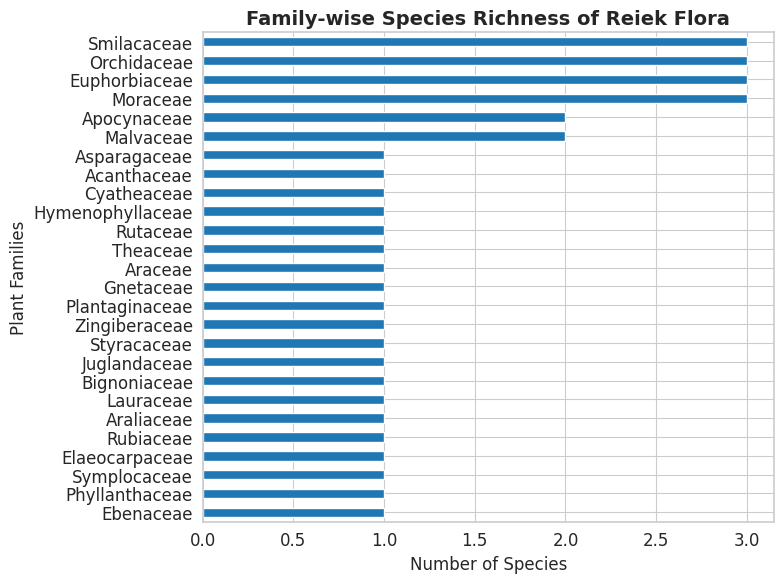

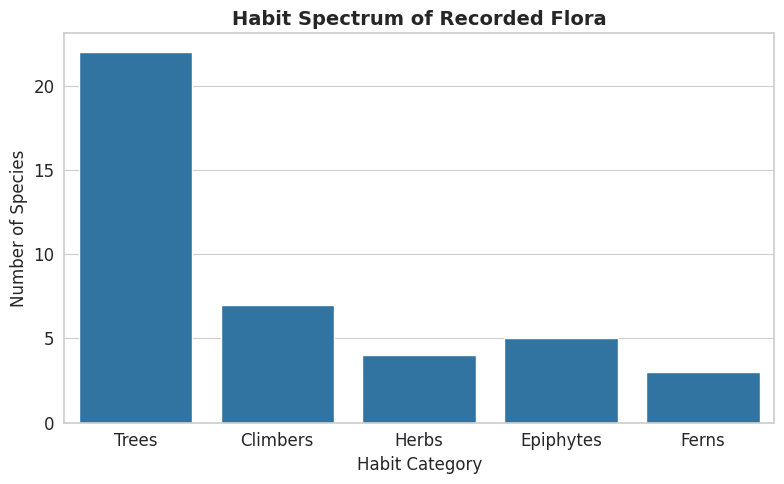

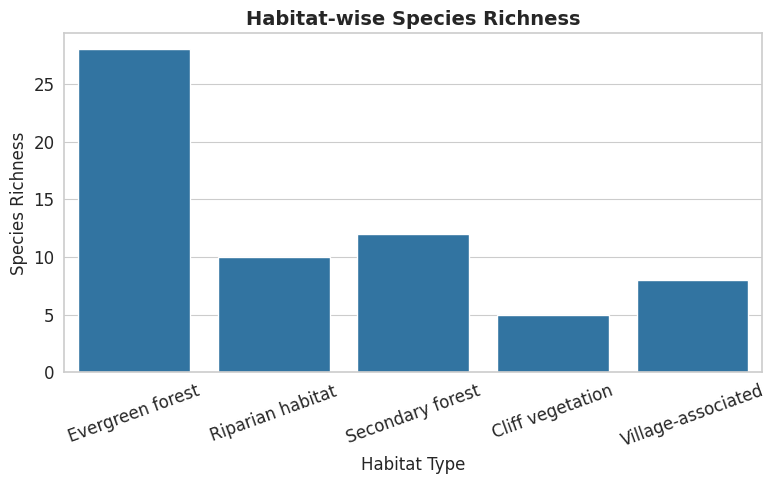

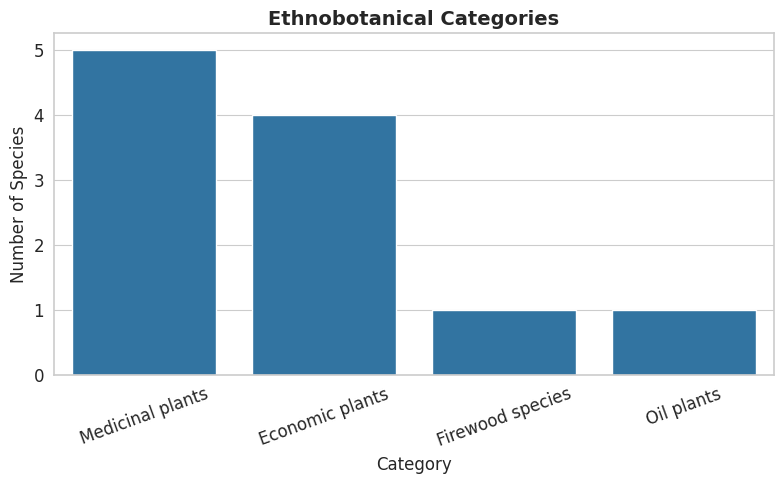

/tmp/ipykernel_9131/3324392313.py:369: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("✓", 1)


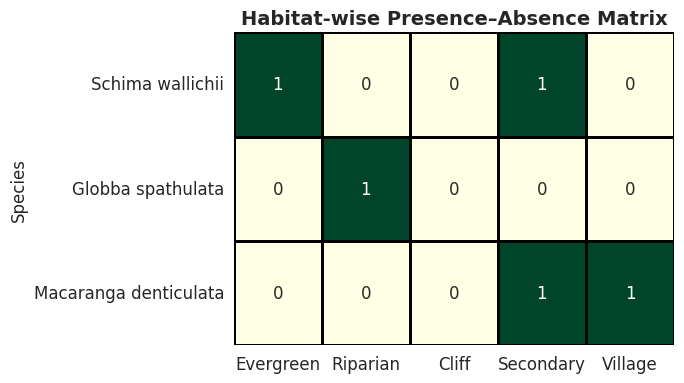

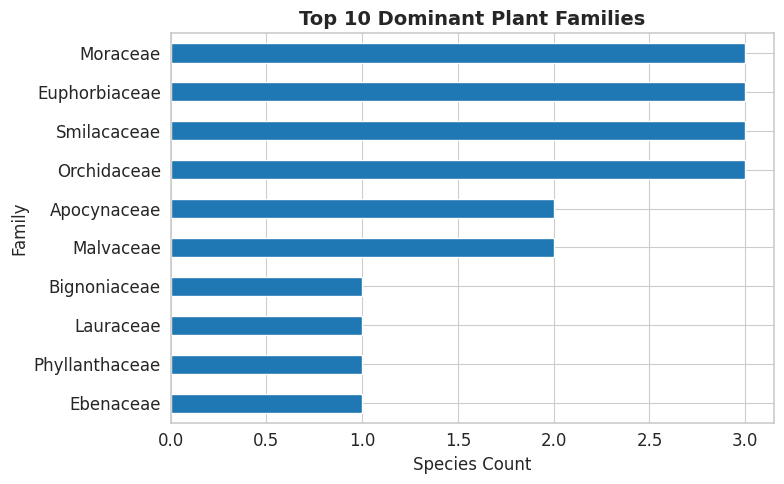


Master checklist exported.
  adding: climbers.csv (deflated 42%)
  adding: Complete_Species_Checklist.csv (deflated 58%)
  adding: ecological_grouping.csv (deflated 26%)
  adding: epiphytes.csv (deflated 31%)
  adding: ethnobotanical.csv (deflated 13%)
  adding: family_richness.csv (deflated 21%)
  adding: ferns.csv (deflated 22%)
  adding: habitat_richness.csv (deflated 14%)
  adding: habit_spectrum.csv (deflated 6%)
  adding: herbs.csv (deflated 30%)
  adding: master_species_dataset.csv (deflated 58%)
  adding: presence_absence.csv (deflated 17%)
  adding: trees_shrubs.csv (deflated 50%)
  adding: Figure1_Family_Richness.png (deflated 23%)
  adding: Figure2_Habit_Spectrum.png (deflated 36%)
  adding: Figure3_Habitat_Richness.png (deflated 20%)
  adding: Figure4_Ethnobotanical.png (deflated 23%)
  adding: Figure5_Presence_Absence.png (deflated 27%)
  adding: Figure6_Top10_Families.png (deflated 32%)
  adding: Figure1_Family_Richness.tiff (deflated 99%)
  adding: Figure2_Habit_Spectru

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



NEXT STEP — UPLOAD TO GITHUB

Create repository:
Reiek-Montane-Floristics-Mizoram

Suggested structure:

data/
figures/
notebooks/

Upload:
- CSV files
- PNG/TIFF figures
- Colab notebook (.ipynb)




In [1]:
# ============================================================
# REIEK MONTANE FLORISTICS — PUBLICATION WORKFLOW
# Google Colab Complete Script
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

!pip install python-docx pandas matplotlib seaborn openpyxl plotly

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

from google.colab import files
from docx import Document

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 3. GLOBAL FIGURE SETTINGS
# ============================================================

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1

sns.set_style("whitegrid")

# ============================================================
# 4. UPLOAD DOCX FILE
# ============================================================

uploaded = files.upload()

# Upload:
# Species Dataset.docx

# ============================================================
# 5. READ DOCX TABLES
# ============================================================

doc = Document("Species Dataset.docx")

tables = doc.tables

print(f"Total tables found: {len(tables)}")

# ============================================================
# 6. EXTRACT TABLES INTO DATAFRAMES
# ============================================================

dfs = []

for i, table in enumerate(tables):

    data = []

    for row in table.rows:
        text = [cell.text.strip() for cell in row.cells]
        data.append(text)

    df = pd.DataFrame(
        data[1:],
        columns=data[0]
    )

    df.columns = df.columns.str.strip()

    dfs.append(df)

    print(f"\nTABLE {i}")
    print(df.head())

# ============================================================
# 7. FIX BROKEN COLUMN HEADERS
# ============================================================

# TABLE 5
dfs[5].columns = ['Family', 'Number_of_Species']

# TABLE 6
dfs[6].columns = ['Habit', 'Species_Count', 'Percentage']

# TABLE 7
dfs[7].columns = ['Habitat', 'Species_Richness']

# TABLE 8
dfs[8].columns = [
    'Ecological_Group',
    'Representative_Species'
]

# TABLE 9
dfs[9].columns = ['Category', 'Number']

# TABLE 10
dfs[10].columns = [
    'Species',
    'Evergreen',
    'Riparian',
    'Cliff',
    'Secondary',
    'Village'
]

# ============================================================
# 8. EXPORT CSV FILES
# ============================================================

dfs[0].to_csv("trees_shrubs.csv", index=False)
dfs[1].to_csv("climbers.csv", index=False)
dfs[2].to_csv("epiphytes.csv", index=False)
dfs[3].to_csv("herbs.csv", index=False)
dfs[4].to_csv("ferns.csv", index=False)

dfs[5].to_csv("family_richness.csv", index=False)
dfs[6].to_csv("habit_spectrum.csv", index=False)
dfs[7].to_csv("habitat_richness.csv", index=False)
dfs[8].to_csv("ecological_grouping.csv", index=False)
dfs[9].to_csv("ethnobotanical.csv", index=False)
dfs[10].to_csv("presence_absence.csv", index=False)

print("CSV files exported successfully.")

# ============================================================
# 9. BUILD MASTER SPECIES DATASET
# ============================================================

trees = pd.read_csv("trees_shrubs.csv")
trees['Habit'] = 'Tree/Shrub'
trees = trees.rename(
    columns={'Ecological Notes':'Notes'}
)

climbers = pd.read_csv("climbers.csv")
climbers['Habit'] = 'Climber'

epiphytes = pd.read_csv("epiphytes.csv")
epiphytes['Habit'] = 'Epiphyte'

herbs = pd.read_csv("herbs.csv")
herbs['Habit'] = 'Herb'

ferns = pd.read_csv("ferns.csv")
ferns['Habit'] = 'Fern'

master = pd.concat([
    trees,
    climbers,
    epiphytes,
    herbs,
    ferns
])

master = master[
    ['Species', 'Family', 'Habit', 'Notes']
]

master.to_csv(
    "master_species_dataset.csv",
    index=False
)

print(master.head())

# ============================================================
# 10. BASIC DATA SUMMARY
# ============================================================

print("\n==============================")
print("FLORISTIC SUMMARY")
print("==============================")

print(
    "Total Species:",
    master['Species'].nunique()
)

print(
    "Total Families:",
    master['Family'].nunique()
)

print(
    "\nDominant Families:"
)

print(
    master['Family'].value_counts().head(10)
)

# ============================================================
# 11. FIGURE 1 — FAMILY RICHNESS
# ============================================================

family_counts = (
    master['Family']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8,6))

family_counts.plot.barh()

plt.xlabel("Number of Species")
plt.ylabel("Plant Families")

plt.title(
    "Family-wise Species Richness of Reiek Flora",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.savefig(
    "Figure1_Family_Richness.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Figure1_Family_Richness.tiff",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 12. FIGURE 2 — HABIT SPECTRUM
# ============================================================

habit = pd.read_csv("habit_spectrum.csv")

plt.figure(figsize=(8,5))

sns.barplot(
    data=habit,
    x='Habit',
    y='Species_Count'
)

plt.ylabel("Number of Species")
plt.xlabel("Habit Category")

plt.title(
    "Habit Spectrum of Recorded Flora",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.savefig(
    "Figure2_Habit_Spectrum.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Figure2_Habit_Spectrum.tiff",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 13. FIGURE 3 — HABITAT-WISE RICHNESS
# ============================================================

habitat = pd.read_csv("habitat_richness.csv")

plt.figure(figsize=(8,5))

sns.barplot(
    data=habitat,
    x='Habitat',
    y='Species_Richness'
)

plt.xticks(rotation=20)

plt.ylabel("Species Richness")
plt.xlabel("Habitat Type")

plt.title(
    "Habitat-wise Species Richness",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.savefig(
    "Figure3_Habitat_Richness.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Figure3_Habitat_Richness.tiff",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 14. FIGURE 4 — ETHNOBOTANICAL CATEGORIES
# ============================================================

ethno = pd.read_csv("ethnobotanical.csv")

plt.figure(figsize=(8,5))

sns.barplot(
    data=ethno,
    x='Category',
    y='Number'
)

plt.xticks(rotation=20)

plt.ylabel("Number of Species")

plt.title(
    "Ethnobotanical Categories",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.savefig(
    "Figure4_Ethnobotanical.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Figure4_Ethnobotanical.tiff",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 15. FIGURE 5 — PRESENCE–ABSENCE HEATMAP
# ============================================================

presence = pd.read_csv(
    "presence_absence.csv"
)

presence = (
    presence
    .replace("✓", 1)
    .fillna(0)
)

presence_numeric = (
    presence
    .set_index("Species")
)

plt.figure(figsize=(7,4))

sns.heatmap(
    presence_numeric,
    cmap='YlGn',
    annot=True,
    cbar=False,
    linewidths=1,
    linecolor='black'
)

plt.title(
    "Habitat-wise Presence–Absence Matrix",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.savefig(
    "Figure5_Presence_Absence.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Figure5_Presence_Absence.tiff",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 16. OPTIONAL — TOP 10 FAMILIES ONLY
# ============================================================

top10 = (
    master['Family']
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(8,5))

top10.plot.barh()

plt.xlabel("Species Count")
plt.ylabel("Family")

plt.title(
    "Top 10 Dominant Plant Families",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.savefig(
    "Figure6_Top10_Families.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 17. EXPORT COMPLETE MASTER CHECKLIST
# ============================================================

master.to_csv(
    "Complete_Species_Checklist.csv",
    index=False
)

print("\nMaster checklist exported.")

# ============================================================
# 18. ZIP ALL OUTPUTS
# ============================================================

!zip -r Reiek_Floristics_Output.zip *.csv *.png *.tiff

# ============================================================
# 19. DOWNLOAD RESULTS
# ============================================================

files.download(
    "Reiek_Floristics_Output.zip"
)

